# 7.3 — LMM: calibración a caplets y estructura de correlación

Dos calibraciones separadas que interactúan: la **volatilidad instantánea** de cada tasa
forward (bootstrap exacto a partir de vols de cap de mercado) y la **correlación** entre
tasas (parametrización de Rebonato de dos parámetros). Con ambas piezas, la fórmula de
aproximación de Rebonato predice la vol implícita de swaption que el LMM calibrado
produciría — se usa para diagnosticar si calibrar exacto a caps deja un ajuste razonable
de swaptions, o si hace falta mover $\beta$.

## 0. Configuración

Reutilizamos la misma malla de tasas forward de 7.1/7.2: $\tau=0.5$, $N=10$ tasas
$L_0,\dots,L_9$ con tiempos de fijación $T_0,\dots,T_9$ derivadas de la curva
Nelson-Siegel de mercado (vía `qflib.market.nelson_siegel_df`).

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, synthetic_cap_vols, synthetic_swaption_vols
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

tau = 0.5
N = 10
T = np.array([tau * (i + 1) for i in range(N + 1)])  # T[0]=0.5 ... T[10]=5.5 (11 nodos)
L0 = np.array([(nelson_siegel_df(T[i]) / nelson_siegel_df(T[i + 1]) - 1.0) / tau for i in range(N)])

print("T (tiempos de fijación L_0..L_9):", np.round(T[:N], 3))
print("L0:", np.round(L0, 5))

T (tiempos de fijación L_0..L_9): [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
L0: [0.04107 0.04342 0.04495 0.04591 0.04647 0.04676 0.04688 0.04688 0.04682
 0.04671]


## 1. Bootstrap exacto de la volatilidad instantánea a partir de caps

Suponemos vol instantánea **constante a trozos por tiempo-a-vencimiento** (estructura
homogénea en el tiempo, el supuesto estándar de mercado): $\sigma_i(t) = b_k$ cuando el
tiempo restante hasta la fijación de $L_i$, $T_i-t$, cae en el $k$-ésimo bucket de ancho
$\tau$ contando desde el vencimiento ($k=0$ es el bucket más cercano a la fijación). Esto
hace que **todas** las tasas compartan el mismo vector de niveles $b_0,\dots,b_{N-1}$
(el mismo bucket $k$ aplica a cualquier tasa que esté a $k$ periodos de fijarse), lo cual
es exactamente lo que da la estructura triangular:

$$(\sigma_i^{\text{Black}})^2 T_i = \sum_{k=0}^{i} b_k^2 \,\tau$$

Como $L_i$ ya fija los primeros $i$ buckets compartidos con $L_0,\dots,L_{i-1}$, sólo
$b_i$ es nuevo en la $i$-ésima ecuación — se despeja secuencialmente, igual que el
bootstrapping de curvas de 5.2: sin optimización, sistema exactamente triangular.

Las vols de cap ATM de mercado ($\sigma_i^{\text{Black}}$) se toman de
`synthetic_cap_vols` evaluada en el strike ATM de cada tasa ($K=L_0(i)$) y en el tenor
igual al propio vencimiento de la tasa ($T_{i+1}$, el pago del caplet).

In [2]:
cap_vols_atm = np.array([
    synthetic_cap_vols(np.array([L0[i]]), np.array([T[i + 1]]))[0, 0] for i in range(N)
])
print("vols de cap ATM (por tasa):", np.round(cap_vols_atm, 5))


def bootstrap_bucket_vols(cap_vols_atm, T, tau):
    '''Bootstrap triangular exacto: b[k] = nivel de vol instantánea del bucket k
    (tiempo-a-vencimiento en (k*tau, (k+1)*tau]), compartido por todas las tasas.'''
    N = len(cap_vols_atm)
    b = np.zeros(N)
    for i in range(N):
        var_target = cap_vols_atm[i] ** 2 * T[i]
        var_known = tau * np.sum(b[:i] ** 2)
        b_i_sq = (var_target - var_known) / tau
        if b_i_sq < 0.0:
            raise ValueError(f"varianza de bucket negativa en i={i}: bootstrap infactible")
        b[i] = np.sqrt(b_i_sq)
    return b


b = bootstrap_bucket_vols(cap_vols_atm, T, tau)
print("niveles de bucket b_0..b_9:", np.round(b, 5))

vols de cap ATM (por tasa): [0.18118 0.17642 0.17308 0.17056 0.16857 0.16694 0.16557 0.16439 0.16336
 0.16244]
niveles de bucket b_0..b_9: [0.18118 0.17153 0.16621 0.16278 0.16036 0.15855 0.1571  0.15589 0.15484
 0.15389]


### Demo 1 — reprecio exacto de los caps de entrada

vol implícita reconstruida: [0.181178 0.176418 0.173082 0.170564 0.168573 0.166944 0.165574 0.164395
 0.163361 0.162438]
vol de cap objetivo:       [0.181178 0.176418 0.173082 0.170564 0.168573 0.166944 0.165574 0.164395
 0.163361 0.162438]

máxima diferencia absoluta en vol: 0.00e+00


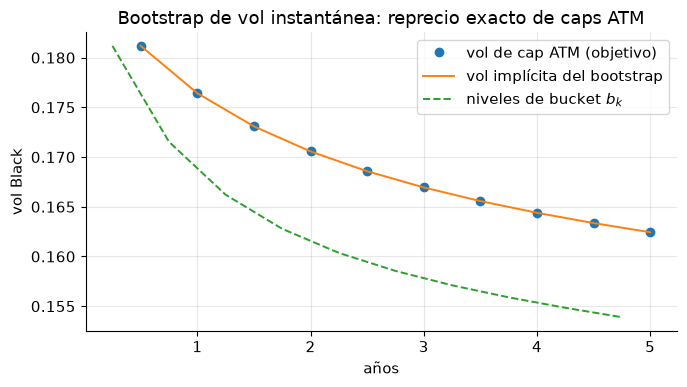

In [3]:
implied_flat_vol = np.array([
    np.sqrt(np.sum(b[:i + 1] ** 2) * tau / T[i]) for i in range(N)
])
max_abs_diff_vol = np.max(np.abs(implied_flat_vol - cap_vols_atm))
print("vol implícita reconstruida:", np.round(implied_flat_vol, 6))
print("vol de cap objetivo:      ", np.round(cap_vols_atm, 6))
print(f"\nmáxima diferencia absoluta en vol: {max_abs_diff_vol:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T[:N], cap_vols_atm, "o", label="vol de cap ATM (objetivo)")
ax.plot(T[:N], implied_flat_vol, "-", label="vol implícita del bootstrap")
ax.plot(np.arange(N) * tau + tau / 2, b, "--", label=r"niveles de bucket $b_k$")
ax.set_xlabel("años"); ax.set_ylabel("vol Black")
ax.set_title("Bootstrap de vol instantánea: reprecio exacto de caps ATM")
ax.legend(); fig.tight_layout()
plt.show()

## 2. Correlación de Rebonato (dos parámetros)

$$\rho_{ij} = \rho_\infty + (1-\rho_\infty)\, e^{-\beta |T_i - T_j|}$$

Positiva definida por construcción (es la suma de $\rho_\infty\,\mathbf{1}\mathbf{1}^\top$ —
semidefinida positiva — y $(1-\rho_\infty)$ veces el kernel exponencial
$e^{-\beta|T_i-T_j|}$ — definido positivo —, con $\rho_\infty\in(0,1)$), simétrica, diagonal 1, y con una correlación
de largo plazo $\rho_\infty>0$ que evita que tasas muy separadas en vencimiento se vuelvan
independientes (poco realista: tasas forward del mismo mercado siempre comparten algo de
riesgo de nivel).

In [4]:
def rebonato_correlation(rho_inf, beta, T_fix):
    '''Matriz de correlación de Rebonato para tiempos de fijación T_fix (N,).'''
    d = np.abs(T_fix[:, None] - T_fix[None, :])
    return rho_inf + (1.0 - rho_inf) * np.exp(-beta * d)


rho_inf, beta = 0.30, 0.10
rho = rebonato_correlation(rho_inf, beta, T[:N])

is_symmetric = np.allclose(rho, rho.T)
diag_is_one = np.allclose(np.diag(rho), 1.0)
eigvals = np.linalg.eigvalsh(rho)
is_psd = np.all(eigvals >= -1e-10)
print(f"simétrica: {is_symmetric} | diagonal=1: {diag_is_one} | PSD: {is_psd} (min eig={eigvals.min():.4f})")

simétrica: True | diagonal=1: True | PSD: True (min eig=0.0179)


### Demo 2 — mapa de calor de la correlación

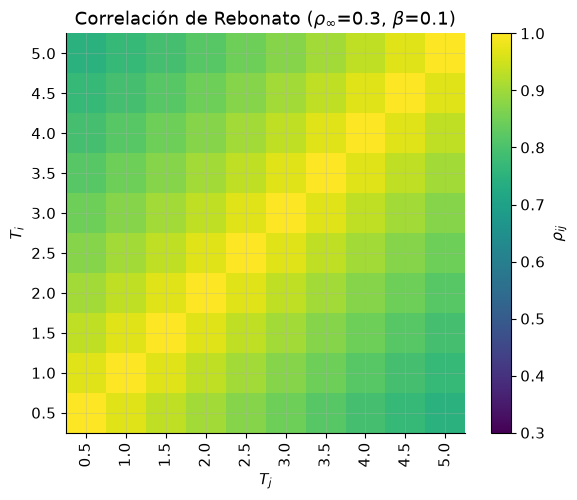

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rho, cmap="viridis", vmin=rho_inf, vmax=1.0, origin="lower")
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(np.round(T[:N], 1), rotation=90)
ax.set_yticklabels(np.round(T[:N], 1))
ax.set_xlabel("$T_j$"); ax.set_ylabel("$T_i$")
ax.set_title(rf"Correlación de Rebonato ($\rho_\infty$={rho_inf}, $\beta$={beta})")
fig.colorbar(im, ax=ax, label=r"$\rho_{ij}$")
fig.tight_layout(); plt.show()

## 3. Consistencia con swaptions: fórmula de aproximación de Rebonato

Para una swaption sobre las tasas $L_\alpha,\dots,L_{\beta-1}$ (fijan en $T_\alpha$, la
tasa swap paga en $T_{\alpha+1},\dots,T_\beta$), la tasa swap es una combinación de
forwards $S(t)=\sum_i w_i(t) L_i(t)$ con pesos que dependen de los factores de descuento
(congelados en $t=0$ para la aproximación):

$$w_i(0) = \frac{\tau\, P(0,T_{i+1})}{\sum_{j=\alpha}^{\beta-1} \tau\, P(0,T_{j+1})}$$

Por la regla de la cadena aplicada a $S=\sum w_i L_i$ (con pesos congelados, la
aproximación clásica), la vol instantánea de $S$ es aproximadamente
$\sum_i w_i \partial S/\partial L_i \,\sigma_i = \sum_i w_i L_i \sigma_i / S$, y su
varianza integrada hasta $T_\alpha$:

$$(\sigma_{\text{swpn}})^2 T_\alpha \approx \sum_{i,j=\alpha}^{\beta-1}
\frac{w_i(0)\,w_j(0)\,L_i(0)\,L_j(0)\,\rho_{ij}}{S(0)^2}\,
\left(\sigma_i^{\text{a }T_\alpha}\right)\left(\sigma_j^{\text{a }T_\alpha}\right) T_\alpha$$

donde $\sigma_i^{\text{a }T_\alpha}$ es la vol RMS (flat) de $L_i$ integrada sólo hasta
$T_\alpha$ (no hasta su propio vencimiento $T_i$) — usa los mismos buckets $b_k$ del
bootstrap de la Sección 1, pero contados desde $t=0$ hasta $T_\alpha$ en vez de hasta
$T_i$.

In [6]:
def par_swap_weights(alpha, beta_n, L0, T, tau):
    '''Pesos w_i(0), tasa swap S(0) y anualidad, vía factores de descuento de la curva spot.'''
    P = np.ones(len(T))
    for k in range(1, len(T)):
        P[k] = P[k - 1] / (1.0 + tau * L0[k - 1])
    Ps = P[alpha + 1:beta_n + 1]
    annuity = tau * np.sum(Ps)
    w = tau * Ps / annuity
    S0 = np.sum(w * L0[alpha:beta_n])
    return w, S0, annuity, P


def flat_vol_to_horizon(i, horizon_bucket_idx, b, tau, T):
    '''Vol RMS de L_i integrada desde t=0 hasta T[horizon_bucket_idx] (buckets 0..horizon-1).'''
    var = 0.0
    for m in range(horizon_bucket_idx):
        k = i - m
        if k >= 0:
            var += b[k] ** 2 * tau
    return np.sqrt(var / T[horizon_bucket_idx]) if var > 0.0 else 0.0


def rebonato_swaption_vol(alpha, beta_n, L0, T, tau, b, rho):
    w, S0, annuity, P = par_swap_weights(alpha, beta_n, L0, T, tau)
    idx = np.arange(alpha, beta_n)
    sigma_h = np.array([flat_vol_to_horizon(i, alpha, b, tau, T) for i in idx])
    rho_sub = rho[np.ix_(idx, idx)]
    num = np.sum(np.outer(w * L0[idx] * sigma_h, w * L0[idx] * sigma_h) * rho_sub)
    return np.sqrt(num / S0 ** 2), w, S0, annuity


alpha, beta_n = 2, 8  # swaption 1.5Yx3Y: expira en T[2]=1.5, tasas L_2..L_7, paga hasta T[8]=4.5
swpn_vol_rebonato, w, S0, annuity = rebonato_swaption_vol(alpha, beta_n, L0, T, tau, b, rho)
print(f"expiry={T[alpha]}, tenor={T[beta_n]-T[alpha]}, S0={S0:.5f}, anualidad={annuity:.4f}")
print(f"vol de swaption aproximada (Rebonato): {swpn_vol_rebonato:.5f}")

expiry=1.5, tenor=3.0, S0=0.04628, anualidad=2.6591
vol de swaption aproximada (Rebonato): 0.12768


### Demo 3 — vol de Rebonato vs superficie sintética de swaptions, y vs una simulación LMM completa

In [7]:
mkt_vol = synthetic_swaption_vols(np.array([T[alpha]]), np.array([T[beta_n] - T[alpha]]))[0, 0]
rel_diff_mkt = abs(swpn_vol_rebonato - mkt_vol) / mkt_vol
print(f"vol de mercado sintética (synthetic_swaption_vols): {mkt_vol:.5f}")
print(f"diferencia relativa Rebonato vs mercado sintético:  {rel_diff_mkt:.2%}")
print("(calibramos EXACTO a caps; la superficie de swaptions queda como diagnóstico, no como target)")

vol de mercado sintética (synthetic_swaption_vols): 0.17392
diferencia relativa Rebonato vs mercado sintético:  26.59%
(calibramos EXACTO a caps; la superficie de swaptions queda como diagnóstico, no como target)


Ahora el chequeo fuerte: reprecio de la misma swaption vía una simulación Monte Carlo
completa del LMM (bajo la medida terminal $Q^{T_N}$, con la vol instantánea bucketizada
de la Sección 1 y la correlación de Rebonato de la Sección 2), comparado contra
Black-76 usando la vol aproximada de Rebonato. Si la aproximación es razonable, ambos
precios deben coincidir dentro de un margen holgado (es una aproximación de primer
orden, no una identidad).

In [8]:
def simulate_lmm_to_alpha(L0, b, rho, tau, alpha_idx, n_steps_per_period, n_paths, rng):
    '''Simula L_0..L_{N-1} desde t=0 hasta T[alpha_idx] bajo la medida terminal Q^{T_N},
    con vol bucketizada (tiempo-a-vencimiento) y correlación rho, log-Euler.'''
    N = len(L0)
    chol = np.linalg.cholesky(rho)
    L = np.tile(L0, (n_paths, 1)).astype(float)
    dt = tau / n_steps_per_period
    for m in range(alpha_idx):
        sigma_t = np.array([b[i - m] if i >= m else 0.0 for i in range(N)])
        for _ in range(n_steps_per_period):
            Z = rng.standard_normal((n_paths, N))
            dW = (Z @ chol.T) * np.sqrt(dt)
            drift = np.zeros((n_paths, N))
            for i in range(N - 1):
                if sigma_t[i] == 0.0:
                    continue
                active = sigma_t[i + 1:] > 0.0
                s = np.sum(
                    tau * rho[i, i + 1:][active] * sigma_t[i + 1:][active] * L[:, i + 1:][:, active]
                    / (1.0 + tau * L[:, i + 1:][:, active]), axis=1)
                drift[:, i] = -sigma_t[i] * L[:, i] * s
            L = L * np.exp((drift - 0.5 * sigma_t ** 2) * dt + sigma_t * dW)
    return L


def black76_price(F, K, T_exp, vol, annuity):
    if vol * np.sqrt(T_exp) < 1e-12:
        return max(F - K, 0.0) * annuity
    d1 = (np.log(F / K) + 0.5 * vol ** 2 * T_exp) / (vol * np.sqrt(T_exp))
    d2 = d1 - vol * np.sqrt(T_exp)
    return annuity * (F * norm.cdf(d1) - K * norm.cdf(d2))


n_paths_swpn = 200_000
L_alpha = simulate_lmm_to_alpha(L0, b, rho, tau, alpha, n_steps_per_period=4,
                                 n_paths=n_paths_swpn, rng=rng)

ratio = np.ones((n_paths_swpn, N + 1))  # ratio[:,k] = P(alpha,T_k)/P(alpha,T_N)
for k in range(N - 1, -1, -1):
    ratio[:, k] = ratio[:, k + 1] * (1.0 + tau * L_alpha[:, k])

annuity_over_PN = tau * np.sum(ratio[:, alpha + 1:beta_n + 1], axis=1)
S_alpha = (ratio[:, alpha] - ratio[:, beta_n]) / annuity_over_PN

K_strike = S0  # ATM
payoff_reweighted = np.maximum(S_alpha - K_strike, 0.0) * annuity_over_PN
price_MC_over_PN = payoff_reweighted.mean()
se_MC_over_PN = payoff_reweighted.std() / np.sqrt(n_paths_swpn)

P0N = nelson_siegel_df(T[N])
price_MC = P0N * price_MC_over_PN
se_price_MC = P0N * se_MC_over_PN

price_rebonato = black76_price(S0, K_strike, T[alpha], swpn_vol_rebonato, annuity)
rel_diff_mc = abs(price_rebonato - price_MC) / price_MC
z_vs_mc = (price_rebonato - price_MC) / se_price_MC

print(f"precio swaption vía MC completo (LMM):        {price_MC:.6f} +- {se_price_MC:.2e}")
print(f"precio swaption vía Black-76 (vol Rebonato):   {price_rebonato:.6f}")
print(f"diferencia relativa (Rebonato vs MC completo): {rel_diff_mc:.2%}  (z={z_vs_mc:.2f})")

precio swaption vía MC completo (LMM):        0.007662 +- 2.79e-05
precio swaption vía Black-76 (vol Rebonato):   0.007670
diferencia relativa (Rebonato vs MC completo): 0.10%  (z=0.27)


### Demo 4 — barrido de $\beta$: ¿mejora el ajuste a la superficie de swaptions sin re-tocar los caplets?

beta que minimiza el error vs superficie sintética de swaptions: 0.020 (error=24.66%, vs error original con beta=0.10: 26.59%)


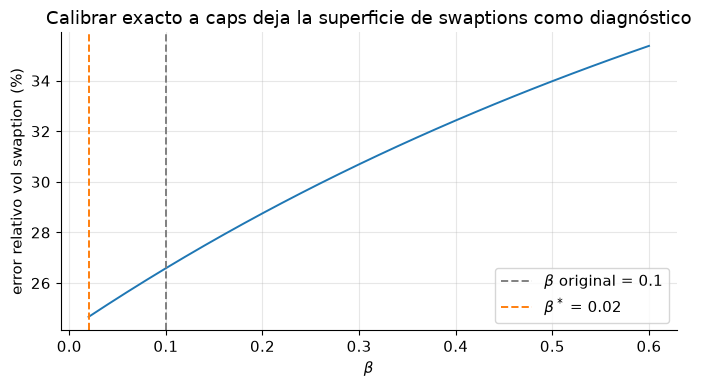


Calibrar exacto a caps + correlación paramétrica no garantiza ajuste de swaptions:
el error residual (incluso en el mejor beta) refleja información de correlación
que los caps por sí solos no pueden pin-pointear -- es el trade-off clásico de LMM.


In [9]:
betas = np.linspace(0.02, 0.60, 30)
errs = []
for beta_i in betas:
    rho_i = rebonato_correlation(rho_inf, beta_i, T[:N])
    vol_i, _, _, _ = rebonato_swaption_vol(alpha, beta_n, L0, T, tau, b, rho_i)
    errs.append(abs(vol_i - mkt_vol) / mkt_vol)
errs = np.array(errs)
beta_star = betas[np.argmin(errs)]
print(f"beta que minimiza el error vs superficie sintética de swaptions: {beta_star:.3f} "
      f"(error={errs.min():.2%}, vs error original con beta={beta:.2f}: {rel_diff_mkt:.2%})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(betas, errs * 100)
ax.axvline(beta, color="gray", ls="--", label=fr"$\beta$ original = {beta}")
ax.axvline(beta_star, color="C1", ls="--", label=fr"$\beta^*$ = {beta_star:.2f}")
ax.set_xlabel(r"$\beta$"); ax.set_ylabel("error relativo vol swaption (%)")
ax.set_title("Calibrar exacto a caps deja la superficie de swaptions como diagnóstico")
ax.legend(); fig.tight_layout(); plt.show()

print("\nCalibrar exacto a caps + correlación paramétrica no garantiza ajuste de swaptions:")
print("el error residual (incluso en el mejor beta) refleja información de correlación")
print("que los caps por sí solos no pueden pin-pointear -- es el trade-off clásico de LMM.")

## 4. Validación

In [10]:
# 1. Bootstrap reprecia exacto los caps de entrada
check1 = max_abs_diff_vol < 1e-6
print(f"1. reprecio exacto de caps (bootstrap): max|diff|={max_abs_diff_vol:.2e} (<1e-6? {check1})")

# 2. Correlación de Rebonato: simétrica, diagonal 1, PSD
check2 = is_symmetric and diag_is_one and is_psd
print(f"2. correlación de Rebonato simétrica/diag=1/PSD: {check2} (min eig={eigvals.min():.4f})")

# 3. vol de swaption de Rebonato vs simulación LMM completa, dentro de rtol=10%
check3 = rel_diff_mc < 0.10
print(f"3. Rebonato vs MC completo: diferencia relativa={rel_diff_mc:.2%} (<10%? {check3})")

assert check1
assert check2
assert check3
print("\nValidación completa: 3/3 dentro de tolerancia.")

1. reprecio exacto de caps (bootstrap): max|diff|=0.00e+00 (<1e-6? True)
2. correlación de Rebonato simétrica/diag=1/PSD: True (min eig=0.0179)
3. Rebonato vs MC completo: diferencia relativa=0.10% (<10%? True)

Validación completa: 3/3 dentro de tolerancia.


## Referencias

- Rebonato, R. (1999). *On the Simultaneous Calibration of Multifactor Lognormal Interest
  Rate Models to Black Volatilities and to the Correlation Matrix*. Journal of
  Computational Finance, 2(4), 5-27.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*
  (2nd ed.), capítulos 6-7. Springer.